In [ ]:
!pip install google-play-scraper
!pip install Sastrawi

In [ ]:
import os
import re
import time
import json
import unicodedata
import string
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from typing import List, Tuple, defaultdict
from collections import Counter
import joblib
import zipfile
import os
from google.colab import files
from google_play_scraper import reviews, Sort

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
import joblib

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#Scraping

In [ ]:
def getreview(app_id, target=2000):
    all_rows, token = [], None
    while True:
        batch, token = reviews(
            app_id,
            lang='id', country='id',
            sort=Sort.NEWEST,
            count=200,
            continuation_token=token
        )
        all_rows.extend(batch)
        print(f"Terkumpul: {len(all_rows)}")
        if not token or len(all_rows) >= target:
            break
        time.sleep(1)
    df = pd.DataFrame(all_rows)[['content', 'score', 'at']]
    df.columns = ['review', 'rating', 'tanggal']
    return df.dropna().drop_duplicates(subset=['review'])

# Tiktok, Instagram, Facebook, Threads
start_time = time.time()
df_tiktok  = getreview('com.zhiliaoapp.musically', 2000); df_tiktok['app']  = 'TikTok'
df_rednote = getreview('com.xingin.xhs',           2000); df_rednote['app'] = 'RedNote'
df_reddit  = getreview('com.reddit.frontpage',     2000); df_reddit['app']  = 'Reddit'

total_time = time.time() - start_time
print(f"\nTotal waktu pengambilan review semua aplikasi: {total_time/60:.2f} menit")

# Menggabungkan semua data
df = pd.concat([df_tiktok, df_rednote, df_reddit], ignore_index=True)
df.to_csv('review_medsos_all.csv', index=False)
df.head(10)

Terkumpul: 200
Terkumpul: 400
Terkumpul: 600
Terkumpul: 800
Terkumpul: 1000
Terkumpul: 1200
Terkumpul: 1400
Terkumpul: 1600
Terkumpul: 1800
Terkumpul: 2000
Terkumpul: 200
Terkumpul: 400
Terkumpul: 600
Terkumpul: 800
Terkumpul: 1000
Terkumpul: 1200
Terkumpul: 1400
Terkumpul: 1600
Terkumpul: 1800
Terkumpul: 2000
Terkumpul: 200
Terkumpul: 400
Terkumpul: 600
Terkumpul: 800
Terkumpul: 1000
Terkumpul: 1200
Terkumpul: 1400
Terkumpul: 1600
Terkumpul: 1800
Terkumpul: 2000

Total waktu pengambilan review semua aplikasi: 0.81 menit


,review,rating,tanggal,app
0,aplikasi yang sangat bagus,5,2025-11-11 11:07:18,TikTok
1,mantap,5,2025-11-11 06:53:55,TikTok
2,"Eu gosto deste aplicativo, ele é muito útil e ...",5,2025-11-11 06:28:19,TikTok
3,Sangat bagus,5,2025-11-11 04:47:42,TikTok
4,mengapa fyp saya tidak bisa di ganti ke Indone...,1,2025-11-10 12:14:17,TikTok
5,tiktok ini sangat bagus bisa membantu dalam be...,5,2025-11-10 09:11:07,TikTok
6,kenapa kalau habis ganti akun ikon komentar fo...,1,2025-11-10 08:26:03,TikTok
7,sangan menghibur,4,2025-11-10 02:50:23,TikTok
8,lancarkan jaringa saya plis,5,2025-11-10 01:14:58,TikTok
9,oke,5,2025-11-09 15:27:11,TikTok


#Data Understanding

In [ ]:
df_tiktok  = df_tiktok.rename(columns={'aplikasi':'app'})
df_rednote = df_rednote.rename(columns={'aplikasi':'app'})
df_reddit  = df_reddit.rename(columns={'aplikasi':'app'})

df = pd.concat([df_tiktok, df_rednote, df_reddit], ignore_index=True)
print(f"TOTAL gabungan: {len(df)}")
print(df['app'].value_counts())


TOTAL gabungan: 4968
app
RedNote    1723
Reddit     1694
TikTok     1551
Name: count, dtype: int64


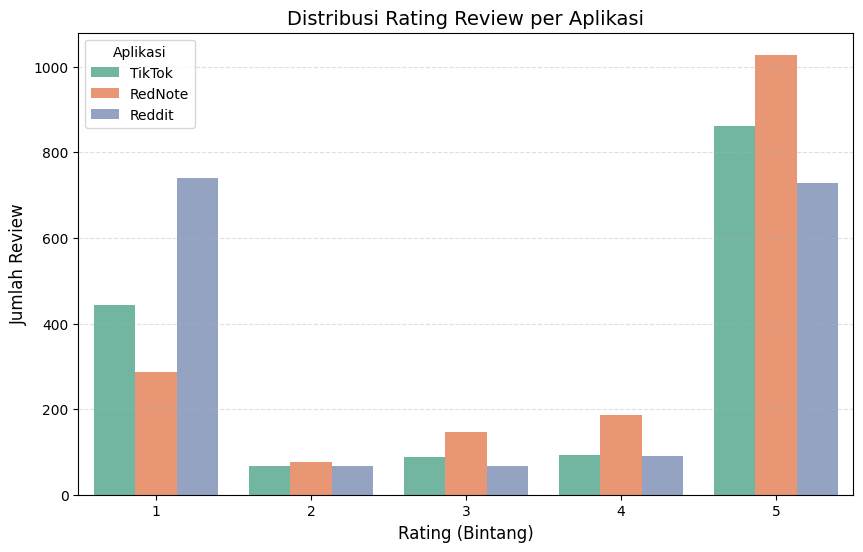

In [ ]:
df_tiktok['aplikasi'] = 'TikTok'
df_rednote['aplikasi'] = 'RedNote'
df_reddit['aplikasi'] = 'Reddit'

df = pd.concat([df_tiktok, df_rednote, df_reddit], ignore_index=True)

# Visualisasi
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x='rating',
    hue='aplikasi',
    palette='Set2'
)

plt.title('Distribusi Rating Review per Aplikasi', fontsize=14)
plt.xlabel('Rating (Bintang)', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)
plt.legend(title='Aplikasi')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [ ]:
# path dataset
path = "/content/review_medsos_all.csv"

# read dataset
df = pd.read_csv(path)
df.head()

,review,rating,tanggal,app
0,aplikasi yang sangat bagus,5,2025-11-11 11:07:18,TikTok
1,mantap,5,2025-11-11 06:53:55,TikTok
2,"Eu gosto deste aplicativo, ele é muito útil e ...",5,2025-11-11 06:28:19,TikTok
3,Sangat bagus,5,2025-11-11 04:47:42,TikTok
4,mengapa fyp saya tidak bisa di ganti ke Indone...,1,2025-11-10 12:14:17,TikTok


In [ ]:
# shape data
df.shape

(4968, 4)

In [ ]:
# ambil fitur reviews dan rating
df = df.iloc[:, :2]
df.head()

,review,rating
0,aplikasi yang sangat bagus,5
1,mantap,5
2,"Eu gosto deste aplicativo, ele é muito útil e ...",5
3,Sangat bagus,5
4,mengapa fyp saya tidak bisa di ganti ke Indone...,1


#Data Labeling

In [ ]:
# function label
def labelling(rating):
  if rating >= 4:
    return 'positif'
  elif rating <= 2:
    return 'negatif'

df['sentiment'] = df['rating'].apply(labelling)
df.head()

,review,rating,sentiment
0,aplikasi yang sangat bagus,5,positif
1,mantap,5,positif
2,"Eu gosto deste aplicativo, ele é muito útil e ...",5,positif
3,Sangat bagus,5,positif
4,mengapa fyp saya tidak bisa di ganti ke Indone...,1,negatif


In [ ]:
# distribusi sentiment
df['sentiment'].value_counts()

,count
sentiment,
positif,2987
negatif,1681


#Data Preprocessing

In [ ]:
# cek nilai null
df.isnull().sum()

,0
review,0
rating,0
sentiment,300


In [ ]:
# drop nilai null
df.dropna(inplace=True)
df.isnull().sum()

,0
review,0
rating,0
sentiment,0


In [ ]:
# cek shape after dropna
df.shape

(4668, 3)

In [ ]:
# config n helper preprocess
url_re     = re.compile(r'(?i)\b(?:https?://|www\.)\S+|pic\.twitter\.com/\S+')
mention_re = re.compile(r'(?<!\w)@[\w_]{1,15}')
hashtag_re = re.compile(r'#(\w+)')
rt_re      = re.compile(r'\bRT\b:?')
number_re  = re.compile(r'\d+')

punct_table = str.maketrans('', '', string.punctuation)

slang = {
    'gk': 'tidak', 'ga': 'tidak', 'gak': 'tidak', 'ngga': 'tidak', 'nggak': 'tidak', 'enggak': 'tidak',  'gx': 'tidak',
    'tp': 'tapi', 'tpi': 'tapi', 'yg': 'yang', 'udh': 'sudah', 'udah': 'sudah', 'sdh': 'sudah', 'dah':'sudah',
    'bgt': 'banget', 'bgts':'banget','bingits':'banget', 'btw': 'ngomong-ngomong', 'sm': 'sama',
    'trs': 'terus', 'trus': 'terus','dr': 'dari', 'jd': 'jadi', 'dgn': 'dengan', 'dg': 'dengan', 'dpt': 'dapat',
    'blm': 'belum', 'aja': 'saja', 'lg': 'lagi', 'krn': 'karena', 'kl': 'kalau', 'klo': 'kalau',
    'km': 'kamu', 'kmu': 'kamu', 'loe': 'kamu', 'lu': 'kamu', 'elo': 'kamu',
    'gw': 'saya', 'gue': 'saya', 'sy': 'saya', 'ane': 'saya', 'gua': 'saya',
    'b aja': 'biasa saja', 'b saja': 'biasa saja',

    'pls': 'tolong', 'makasih': 'terima kasih', 'makasi': 'terima kasih', 'nuwun': 'terima kasih',
    'thx': 'terima kasih', 'thanks': 'terima kasih', 'terimakasih': 'terima kasih',
    'mantul': 'mantap betul', 'parah': 'buruk', 'fix': 'pasti', 'sumpah': 'sungguh',
    'anjay': 'bagus', 'wow': 'bagus', 'kereen': 'keren', 'mantap': 'bagus', 'kece':'bagus',
    'bgs':'bagus','baguss': 'bagus', 'jelek': 'buruk', 'jlk':'buruk', 'gaje':'tidak jelas', 'gakjelas': 'tidak jelas',
    'lola': 'loading lama', 'lemot': 'lambat', 'seruh':'seru', 'gaseru': 'tidak seru',
    'worthit': 'layak', 'worth': 'layak', 'recommended': 'disarankan', 'rekomen': 'disarankan',
    'ok': 'baik', 'okay': 'baik', 'oke': 'baik', 'sip': 'baik', 'good': 'bagus',

    'bug': 'kesalahan', 'error': 'kesalahan', 'crash': 'berhenti tiba-tiba',
    'lag': 'lambat', 'ngelag':'lambat', 'update': 'pembaruan', 'install': 'pasang', 'uninstall': 'hapus',
    'login': 'masuk', 'logout': 'keluar', 'signup': 'daftar', 'register': 'daftar',
    'fitur': 'fitur', 'notif': 'notifikasi', 'akun': 'akun', 'app': 'aplikasi',
    'apk': 'aplikasi',

    'bnyk': 'banyak', 'org': 'orang', 'pdhl': 'padahal', 'cpt': 'cepat', 'br': 'baru', 'bgmn': 'bagaimana',
    'gmn': 'bagaimana', 'mnt': 'menit', 'jg': 'juga', 'tdr': 'tidur', 'blg': 'bilang',
    'sbnrnya': 'sebenarnya', 'bbrp': 'beberapa', 'smua': 'semua', 'dmn': 'dimana',
    'lgsg': 'langsung', 'kyk': 'seperti', 'tmn': 'teman', 'pake': 'pakai', 'ngapain': 'kenapa',
    'nyoba': 'mencoba', 'dapet': 'dapat', 'sampe': 'sampai', 'emang': 'memang', 'utk': 'untuk',
    'lbh': 'lebih', 'cm': 'cuma', 'dll': 'dan lain-lain', 'dlm': 'dalam', 'bikin': 'membuat',
    'brp': 'berapa', 'masi': 'masih', 'bener': 'benar', 'guna':'berguna',

    'kecewa': 'buruk', 'ngebug': 'kesalahan', 'ngehang': 'berhenti', 'ngecrash': 'berhenti', 'kece': 'bagus', 'enak': 'bagus',
    'seru': 'menyenangkan', 'nyenengin': 'menyenangkan', 'bosen': 'membosankan', 'boring': 'membosankan',
    'malah': 'justru', 'tolongin': 'tolong', 'tolonglah': 'tolong',
    'terbaik': 'bagus', 'terburuk': 'buruk', 'payah': 'buruk', 'aneh': 'tidak biasa',
    "aplikasih": "aplikasi", "aplikasihnya": "aplikasi", "bokep": "konten_dewasa"
}

In [ ]:
# function utils preprocess
def normalize_elongation(word: str, max_repeat: int = 2) -> str:
    return re.sub(r'(.)\1{2,}', r'\1' * max_repeat, word)

def remove_emoji(text: str) -> str:
    return ''.join(ch for ch in text if not unicodedata.category(ch).startswith('So'))

def preprocess_tweet(text: str) -> str:
    text = text.strip()
    text = html.unescape(text)
    text = text.lower()

    # hapus url
    text = url_re.sub(' <url> ', text)
    # hapus mention + usn (e.g @jokowi)
    text = mention_re.sub(' ', text)
    # hapus RT
    text = rt_re.sub(' ', text)
    # #hashtag → kata
    text = hashtag_re.sub(r' \1 ', text)
    # hapus angka
    text = number_re.sub(' ', text)
    # hapus emoji
    text = remove_emoji(text)

    # tokenisasi
    toks = text.split()
    norm = []
    for w in toks:
        w = normalize_elongation(w)
        if w in slang:
            w = slang[w]
        norm.append(w)
    text = " ".join(norm)

    # hapus tanda baca
    text = text.replace('<', ' <').replace('>', '> ')
    text = text.translate(punct_table)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

tqdm.pandas(desc="Preprocessing")
df["text_clean"] = df['review'].progress_apply(preprocess_tweet)
df.head()

Preprocessing: 100%|██████████| 4668/4668 [00:00<00:00, 20506.20it/s]


,review,rating,sentiment,text_clean
0,aplikasi yang sangat bagus,5,positif,aplikasi yang sangat bagus
1,mantap,5,positif,bagus
2,"Eu gosto deste aplicativo, ele é muito útil e ...",5,positif,eu gosto deste aplicativo ele é muito útil e m...
3,Sangat bagus,5,positif,sangat bagus
4,mengapa fyp saya tidak bisa di ganti ke Indone...,1,negatif,mengapa fyp saya tidak bisa di ganti ke indone...


In [ ]:
# stopword removal (Indonesian)
ID_STOPWORDS = stopwords.words('indonesian')

def remove_stopwords(s: str, custom_stopwords: List[str] = None) -> str:
    toks = s.split()
    all_stopwords = set(ID_STOPWORDS)
    if custom_stopwords:
        all_stopwords.update(custom_stopwords)
    kept = [t for t in toks if t not in all_stopwords]
    return " ".join(kept)

# stemming
def stem_text(s: str) -> str:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    return stemmer.stem(s)

# apply remove sw
custom_stop = ["username", "usn", "id"]
df["text_clean"] = df["text_clean"].progress_apply(lambda x: remove_stopwords(x, custom_stopwords=custom_stop))

# apply stem
df["text_clean"] = df["text_clean"].progress_apply(stem_text)
df.head()

Preprocessing: 100%|██████████| 4668/4668 [24:11<00:00,  3.22it/s]


,review,rating,sentiment,text_clean
0,aplikasi yang sangat bagus,5,positif,aplikasi bagus
1,mantap,5,positif,bagus
2,"Eu gosto deste aplicativo, ele é muito útil e ...",5,positif,eu gosto deste aplicativo ele muito til e me d...
3,Sangat bagus,5,positif,bagus
4,mengapa fyp saya tidak bisa di ganti ke Indone...,1,negatif,fyp ganti indonesia ikut saran tik tok hasil


In [ ]:
print("Contoh hasil cleaning:")
df[["review","text_clean","rating","sentiment"]].head()

Contoh hasil cleaning:


,review,text_clean,rating,sentiment
0,aplikasi yang sangat bagus,aplikasi bagus,5,positif
1,mantap,bagus,5,positif
2,"Eu gosto deste aplicativo, ele é muito útil e ...",eu gosto deste aplicativo ele muito til e me d...,5,positif
3,Sangat bagus,bagus,5,positif
4,mengapa fyp saya tidak bisa di ganti ke Indone...,fyp ganti indonesia ikut saran tik tok hasil,1,negatif


In [ ]:
# save hasil prepro
df.to_csv("review_medsos_all_clean.csv", index=False)

In [ ]:
# path dataset
path_clean = "/content/review_medsos_all.csv"

# read dataset
df_clean = pd.read_csv(path_clean)
df_clean.shape

(4968, 4)

#EDA

#Distribusi Label

/tmp/ipython-input-4043019609.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=vc.index, y=vc.values, palette="viridis")


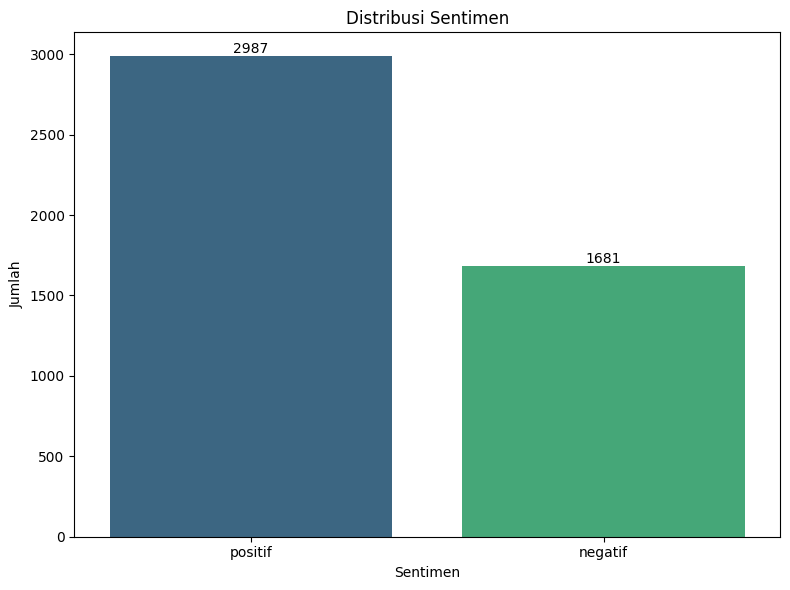

In [ ]:
vc = df["sentiment"].value_counts()

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=vc.index, y=vc.values, palette="viridis")
ax.set_title("Distribusi Sentimen")
ax.set_xlabel("Sentimen")
ax.set_ylabel("Jumlah")

# add labbel
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

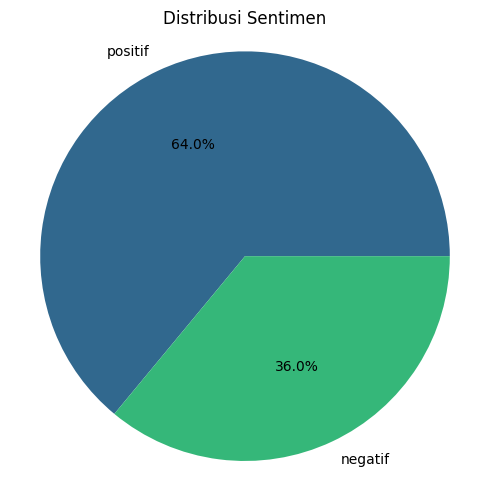

In [ ]:
# piechart
plt.figure(figsize=(5, 5))
plt.pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(vc)))
plt.title("Distribusi Sentimen")
plt.axis('equal')
plt.tight_layout()
plt.show()

##WordCloud Seluruh Data

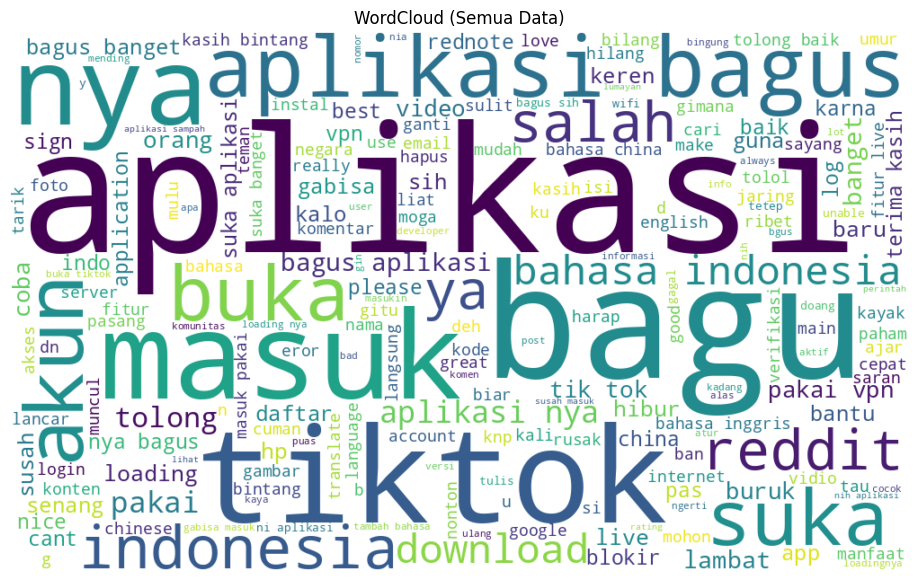

In [ ]:
wc_text = " ".join(df["text_clean"].tolist())

wc = WordCloud(width=1000, height=600, background_color="white").generate(wc_text)
plt.figure(figsize=(12,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud (Semua Data)")
plt.show()

##WordCloud Per Sentimen

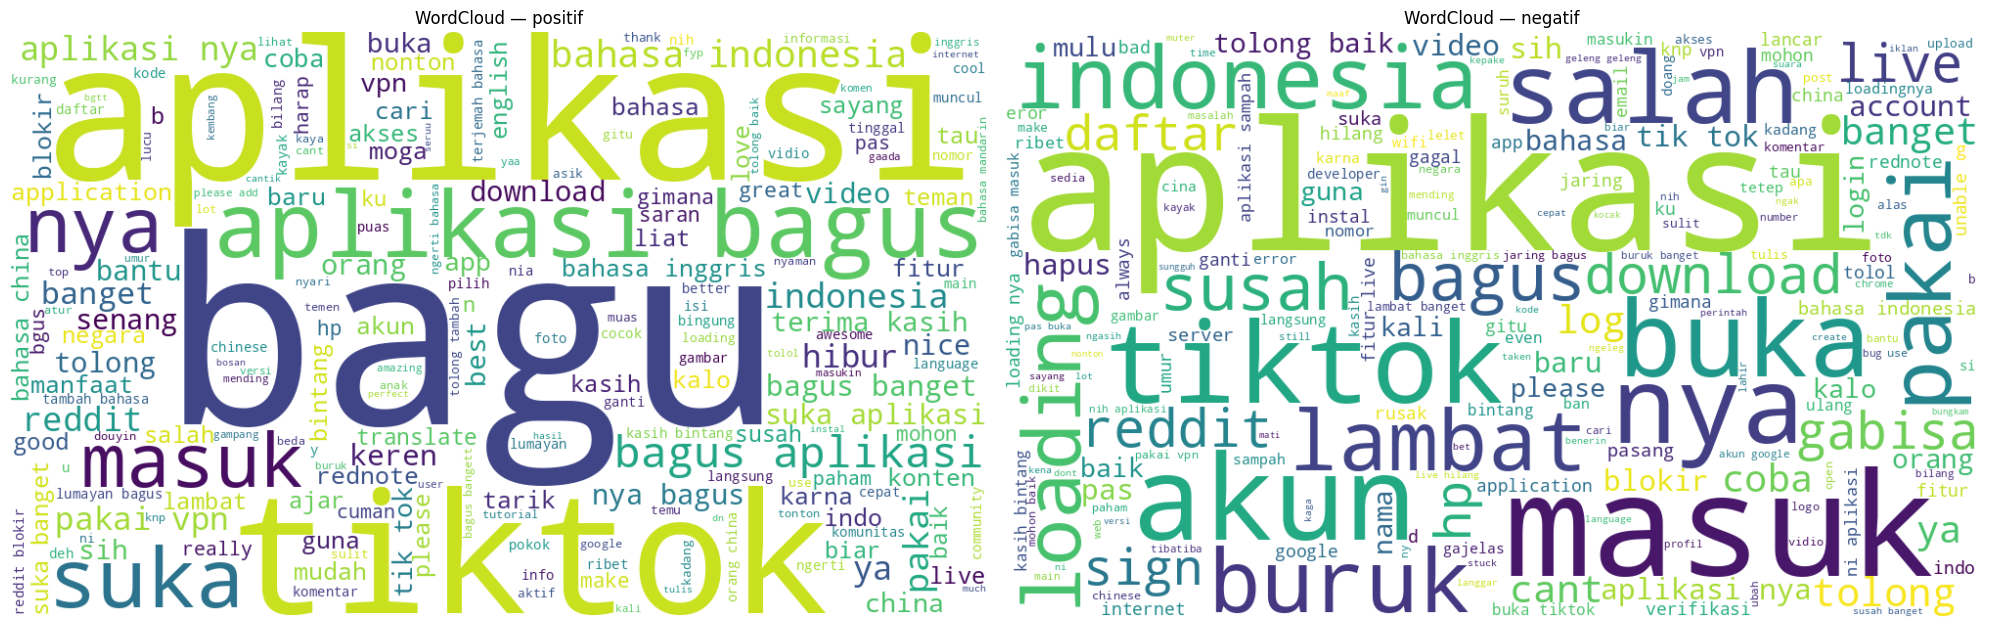

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for i, label in enumerate(["positif", "negatif"]):
    sub = df.loc[df["sentiment"]==label, "text_clean"]
    if sub.empty:
        continue
    text = " ".join(sub.tolist())
    wc = WordCloud(width=1000, height=600, background_color="white").generate(text)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"WordCloud — {label}")

plt.tight_layout()
plt.show()

ps. karena pada wordcloud diatas terlihat bahwa ada beberapa kata yang overlap (bersebrangan) maka akan dilakukan penghapusan kata tersebut agar hasil terlihat lebih jelas antar sentiment

##Removal Overlap

In [ ]:
# hitung frekuensi per kelas
freq_by_cls = {}
for s in df["sentiment"].unique():
    toks = " ".join(df.loc[df["sentiment"]==s, "text_clean"].astype(str)).split()
    freq_by_cls[s] = Counter(toks)

# cari token yang “bersebrangan”
presence = defaultdict(int)
for s, cnt in freq_by_cls.items():
    for w, c in cnt.items():
        if c >= 3:
            presence[w] += 1

overlap_tokens = {w for w, k in presence.items() if k >= 2}
print("Jumlah token overlap:", len(overlap_tokens))

Jumlah token overlap: 378


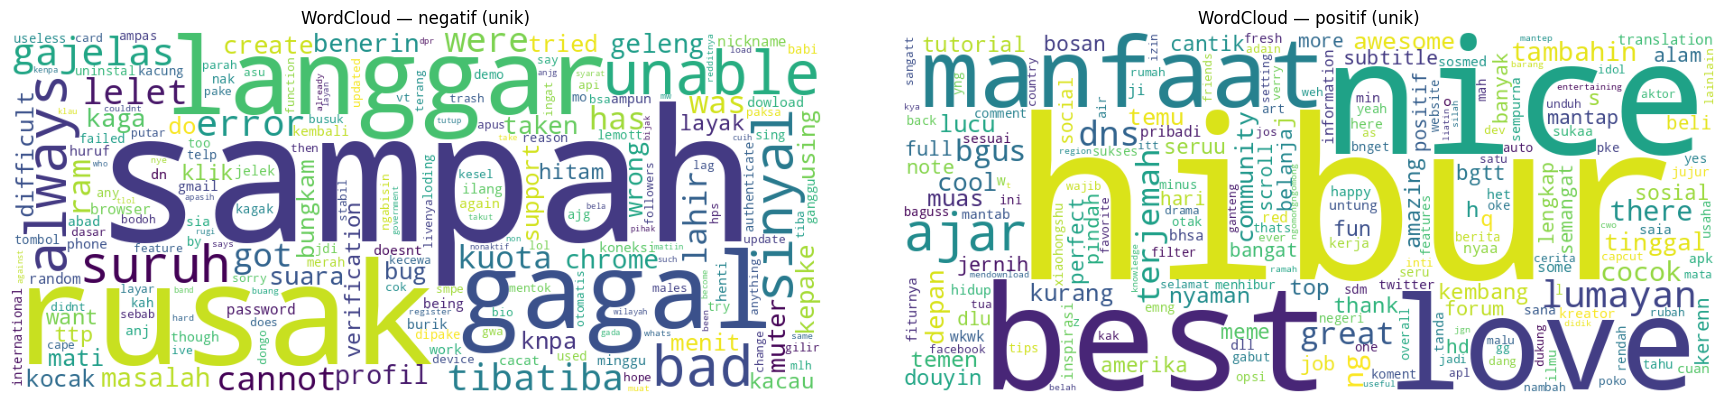

In [ ]:
# filter frekuensi
uniq_freq_by_cls = {
    s: Counter({w:c for w,c in cnt.items() if w not in overlap_tokens})
    for s, cnt in freq_by_cls.items()
}

plt.figure(figsize=(18,4))
for i, s in enumerate(sorted(uniq_freq_by_cls.keys())):
    plt.subplot(1, len(uniq_freq_by_cls), i+1)
    wc = WordCloud(width=900, height=400, background_color="white").generate_from_frequencies(uniq_freq_by_cls[s])
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"WordCloud — {s} (unik)")

plt.tight_layout()
plt.show()

In [ ]:
df_overlap = pd.DataFrame(
    {"token": list(overlap_tokens)}
).sort_values("token").reset_index(drop=True)

# hapus token overlap dari tiap dokumen
def drop_overlap_words(text: str) -> str:
    if not isinstance(text, str):
        return ""
    toks = text.split()
    toks = [t for t in toks if t not in overlap_tokens]
    return " ".join(toks)

df["text_final"] = df["text_clean"].astype(str).apply(drop_overlap_words)
df.head()

,review,rating,sentiment,text_clean,text_final
0,aplikasi yang sangat bagus,5,positif,aplikasi bagus,
1,mantap,5,positif,bagus,
2,"Eu gosto deste aplicativo, ele é muito útil e ...",5,positif,eu gosto deste aplicativo ele muito til e me d...,eu gosto deste aplicativo ele muito til e diverte
3,Sangat bagus,5,positif,bagus,
4,mengapa fyp saya tidak bisa di ganti ke Indone...,1,negatif,fyp ganti indonesia ikut saran tik tok hasil,


In [ ]:
# cek baris kosong
df["text_final"] = df["text_final"].fillna("").str.strip()
df["n_tok_fix"] = df["text_final"].str.split().str.len()
print("Baris kosong:", (df["n_tok_fix"]==0).sum())

Baris kosong: 1479


In [ ]:
mask = df["n_tok_fix"] == 0
df.loc[mask, "text_final"] = df.loc[mask, "text_clean"].astype(str).str.strip()
df["n_tok_fix"] = df["text_final"].str.split().str.len()

df = df[df["n_tok_fix"] > 0].copy()
df.drop(columns=["n_tok_fix"], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4440 entries, 0 to 4967
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   review      4440 non-null   object
 1   rating      4440 non-null   int64 
 2   sentiment   4440 non-null   object
 3   text_clean  4440 non-null   object
 4   text_final  4440 non-null   object
dtypes: int64(1), object(4)
memory usage: 208.1+ KB


#Data Modelling & Evaluation

In [ ]:
# mapping sentiment
df["label"] = df["sentiment"].map({"positif": 1, "negatif": 0})
df.head()

,review,rating,sentiment,text_clean,text_final,label
0,aplikasi yang sangat bagus,5,positif,aplikasi bagus,aplikasi bagus,1
1,mantap,5,positif,bagus,bagus,1
2,"Eu gosto deste aplicativo, ele é muito útil e ...",5,positif,eu gosto deste aplicativo ele muito til e me d...,eu gosto deste aplicativo ele muito til e diverte,1
3,Sangat bagus,5,positif,bagus,bagus,1
4,mengapa fyp saya tidak bisa di ganti ke Indone...,1,negatif,fyp ganti indonesia ikut saran tik tok hasil,fyp ganti indonesia ikut saran tik tok hasil,0


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import numpy as np

In [ ]:
# splitting data 80:20
test_size = 0.2
random_state = 42

X = df["text_clean"]
y = df["label"]

In [ ]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)
print(f"Train: {len(y_train)} | Test: {len(y_test)}")

Train: 3552 | Test: 888


In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    smooth_idf=True,
    norm="l2",
    strip_accents="unicode",
    max_features=60000
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(3552, 1508) (888, 1508)


In [ ]:
#SVM (linear)
svm_lin = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42,
    max_iter=5000,
    dual=True
)

svm_lin.fit(X_train_tfidf, y_train)

#RandomForest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500, n_jobs=-1,
                       random_state=42)

In [ ]:
def evaluate_model(name, model, X_test_mat, y_test):
    t0 = time.time()
    y_pred = model.predict(X_test_mat)
    infer_time = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])  # baris: True POS, True NEG

    print(f"\n{name}")
    print(f"Infer time: {infer_time:.2f}s")
    print(f"Accuracy: {acc:.4f} | Precision: {p:.4f} | Recall: {r:.4f} | F1: {f1:.4f}")
    print("\nConfusion Matrix [rows: True POS, True NEG | cols: Pred POS, Pred NEG]:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"], zero_division=0))

    return {"Model": name, "Accuracy": acc, "Precision": p, "Recall": r, "F1": f1,
            "Infer(s)": infer_time, "cm": cm, "y_pred": y_pred}

# PERHATIKAN: pakai X_test sesuai tipe
res_svm = evaluate_model("SVM (Linear) + TF-IDF", svm_lin, X_test_tfidf,               y_test)         # sparse OK
res_rf  = evaluate_model("RandomForest + TF-IDF",  rf,      X_test_tfidf.toarray(),    y_test)         # dense


SVM (Linear) + TF-IDF
Infer time: 0.00s
Accuracy: 0.8119 | Precision: 0.8475 | Recall: 0.8551 | F1: 0.8513

Confusion Matrix [rows: True POS, True NEG | cols: Pred POS, Pred NEG]:
[[478  81]
 [ 86 243]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.74      0.74       329
    Positive       0.85      0.86      0.85       559

    accuracy                           0.81       888
   macro avg       0.80      0.80      0.80       888
weighted avg       0.81      0.81      0.81       888


RandomForest + TF-IDF
Infer time: 1.24s
Accuracy: 0.8311 | Precision: 0.8425 | Recall: 0.8998 | F1: 0.8702

Confusion Matrix [rows: True POS, True NEG | cols: Pred POS, Pred NEG]:
[[503  56]
 [ 94 235]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.71      0.76       329
    Positive       0.84      0.90      0.87       559

    accuracy                           0.83       888

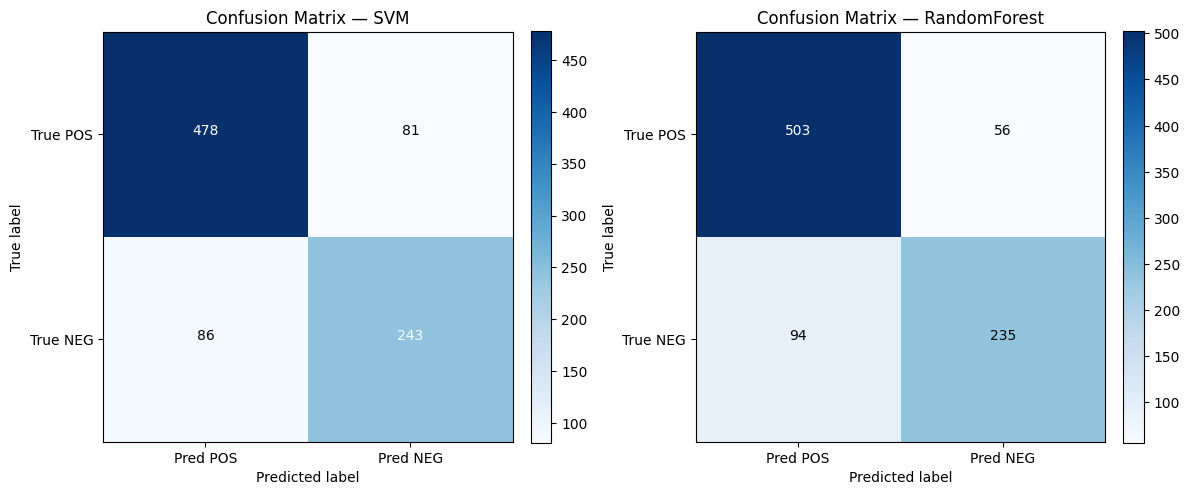

In [ ]:
def plot_cm(cm, title, ax, cmap='viridis'):
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(2)); ax.set_yticks(np.arange(2))
    ax.set_xticklabels(["Pred POS", "Pred NEG"])
    ax.set_yticklabels(["True POS", "True NEG"])
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center",
                    color="white" if cm[i, j] > thresh else "black")
    ax.set_ylabel("True label"); ax.set_xlabel("Predicted label")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_cm(res_svm["cm"], "Confusion Matrix — SVM",          axes[0], cmap='Blues')  # <- pakai res_svm, BUKAN svm_lin
plot_cm(res_rf["cm"],  "Confusion Matrix — RandomForest", axes[1], cmap='Blues')
plt.tight_layout(); plt.show()

In [ ]:
# Tabel perbandingan metrik
comp = pd.DataFrame([{
    "Model": r["Model"],
    "Accuracy (%)": round(r["Accuracy"]*100, 2),
    "Precision (%)": round(r["Precision"]*100, 2),
    "Recall (%)": round(r["Recall"]*100, 2),
    "F1 (%)": round(r["F1"]*100, 2),
    "Infer (s)": round(r["Infer(s)"], 2),
} for r in [res_svm, res_rf]]).sort_values("F1 (%)", ascending=False)
display(comp)

,Model,Accuracy (%),Precision (%),Recall (%),F1 (%),Infer (s)
1,RandomForest + TF-IDF,83.11,84.25,89.98,87.02,1.24
0,SVM (Linear) + TF-IDF,81.19,84.75,85.51,85.13,0.00


#Simpan Model

In [ ]:
# save model
vec_path  = "/content/tfidf_vectorizer.joblib"
svm_path  = "/content/svm_linear_model.joblib"
rf_path   = "/content/random_forest_model.joblib"
meta_path = "/content/metadata.json"
zip_path  = "/content/artifacts.zip"

# simpan objek
joblib.dump(tfidf_vectorizer, vec_path)
joblib.dump(svc, svm_path)
joblib.dump(rf, rf_path)

# metadata ringkas
meta = {
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "vectorizer": "sklearn.feature_extraction.text.TfidfVectorizer",
    "models": ["svm_rbf_model.joblib", "random_forest_model.joblib"],
    "labels": {"negative": 0, "positive": 1}
}
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

# zip file
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in [vec_path, svm_path, rf_path, meta_path]:
        z.write(p, arcname=os.path.basename(p))

files.download(zip_path)

MENGETAHUI DATA YANG SALAH (misclassification)

In [ ]:
# --- prediksi dari model yang sudah kamu fit ---
y_pred_svc = svc.predict(X_test_tfidf.toarray())     # SVM RBF
y_pred_rf  = rf.predict(X_test_tfidf)                # RandomForest

# --- rangkai tabel audit dengan indeks asli dari df ---
audit = pd.DataFrame({
    "review":     df.loc[X_test.index, "review"],
    "text_clean": df.loc[X_test.index, "text_clean"],
    "true":       y_test.values,
    "pred_svc":   y_pred_svc,
    "pred_rf":    y_pred_rf
}, index=X_test.index)

# label nama (opsional)
label_map = {0:"negatif", 1:"positif"}
audit["true_lbl"]    = audit["true"].map(label_map)
audit["pred_svc_lbl"]= audit["pred_svc"].map(label_map)
audit["pred_rf_lbl"] = audit["pred_rf"].map(label_map)

# tipe kesalahan per model
def err_type(y_true, y_pred):
    if y_true==y_pred: return "OK"
    return "FN" if (y_true==1 and y_pred==0) else "FP"

audit["svc_err"] = [err_type(t,p) for t,p in zip(audit["true"], audit["pred_svc"])]
audit["rf_err"]  = [err_type(t,p) for t,p in zip(audit["true"], audit["pred_rf"])]

# --- filter salah prediksi ---
miss_svc = audit[audit["svc_err"].isin(["FP","FN"])]
miss_rf  = audit[audit["rf_err"].isin(["FP","FN"])]

print("Salah SVM:", miss_svc.shape[0])
print("Salah RF :", miss_rf.shape[0])

# lihat contoh
miss_svc.head(10)

In [ ]:
#miss_svc.to_csv("misclassified_svm.csv", index=True)   # index = baris asli di df
#miss_rf.to_csv("misclassified_rf.csv", index=True)


In [ ]:
import numpy as np

feat_names = tfidf_vectorizer.get_feature_names_out()

def top_terms_for_indices(idxs, X_mat, k=20):
    mask = X_test.index.isin(idxs)
    sub = X_mat[mask]
    means = np.asarray(sub.mean(axis=0)).ravel()
    top = means.argsort()[::-1][:k]
    return [(feat_names[i], round(means[i],6)) for i in top]

# daftar index FP & FN SVM
idx_fp_svc = miss_svc.index[miss_svc["svc_err"]=="FP"]
idx_fn_svc = miss_svc.index[miss_svc["svc_err"]=="FN"]

print("Top terms SVM FP:", top_terms_for_indices(idx_fp_svc, X_test_tfidf, k=20))
print("Top terms SVM FN:", top_terms_for_indices(idx_fn_svc, X_test_tfidf, k=20))


In [ ]:
import numpy as np
import pandas as pd

feat_names = tfidf_vectorizer.get_feature_names_out()

def top_terms_table(idxs, X_mat, all_index, k=20):
    """
    idxs      : index baris yang ingin dianalisis (mis. index FP/FN)
    X_mat     : matriks TF-IDF untuk X_test (sparse)
    all_index : X_test.index (agar masking sesuai urutan)
    k         : banyaknya term teratas
    """
    idxs = list(idxs)
    if len(idxs) == 0:
        return pd.DataFrame(columns=["term", "mean_tfidf", "doc_freq"])

    mask = all_index.isin(idxs)
    sub = X_mat[mask]

    means = np.asarray(sub.mean(axis=0)).ravel()              # rerata tf-idf per term
    docfreq = np.asarray((sub > 0).sum(axis=0)).ravel()       # berapa dokumen berisi term
    top = means.argsort()[::-1][:k]

    tbl = pd.DataFrame({
        "term": feat_names[top],
        "mean_tfidf": means[top],
        "doc_freq": docfreq[top].astype(int)
    })
    return tbl

# --- ambil index salah SVM ---
idx_fp_svc = miss_svc.index[miss_svc["svc_err"]=="FP"]
idx_fn_svc = miss_svc.index[miss_svc["svc_err"]=="FN"]
idx_fp_rf = miss_rf.index[miss_rf["rf_err"]=="FP"]
idx_fn_rf = miss_rf.index[miss_rf["rf_err"]=="FN"]

# --- buat tabel ---
tbl_fp_svc = top_terms_table(idx_fp_svc, X_test_tfidf, X_test.index, k=20)
tbl_fn_svc = top_terms_table(idx_fn_svc, X_test_tfidf, X_test.index, k=20)
tbl_fp_rf = top_terms_table(idx_fp_rf, X_test_tfidf, X_test.index, k=20)
tbl_fn_rf = top_terms_table(idx_fn_rf, X_test_tfidf, X_test.index, k=20)



In [ ]:
# tampilkan
print("Top terms SVM – FP (pred POS tapi seharusnya NEG):")
display(tbl_fp_svc)
print("Top terms SVM – FN (pred NEG tapi seharusnya POS):")
display(tbl_fn_svc)


In [ ]:
print("Top terms RF – FP (pred POS tapi seharusnya NEG):")
display(tbl_fp_rf)

print("Top terms RF – FN (pred NEG tapi seharusnya POS):")
display(tbl_fn_rf)